<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install pyodide-build


Note: you may need to restart the kernel to use updated packages.


### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [7]:
import micropip
await micropip.install("pyodide-http")

import pyodide_http
pyodide_http.patch_all()  # patches requests/urllib to work in Pyodide

import requests
r = requests.get(URL)
with open("dataset.csv", "wb") as f:
    f.write(r.content)

---


# Test Environment


In [8]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts

import pandas as pd
file_name = "dataset.csv"
# Path to the CSV file
file_path = file_name

# Read the CSV into a DataFrame. By default, header=0, so the first row is treated as column names.
df = pd.read_csv(file_path)

# Optional: display basic information about the loaded DataFrame
print(df.head())
print('Rows:', len(df), 'Columns:', len(df.columns))

   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           1         Dell         3    Full HD    1   1         3   
2           2         Dell         3    Full HD    1   1         7   
3           3         Dell         4  IPS Panel    2   1         5   
4           4           HP         4    Full HD    2   1         7   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0          35.560            1.6       8             256       1.60    978  
1          39.624            2.0       4             256       2.20    634  
2          39.624            2.7       8             256       2.20    946  
3          33.782            1.6       8             128       1.22   1244  
4          39.624            1.8       8             256       1.91    837  
Rows: 238 Columns: 13


In [9]:
missing_counts = df.isna().sum()
missing_columns = missing_counts[missing_counts > 0]

print(missing_columns)

Screen_Size_cm    4
Weight_kg         5
dtype: int64


In [10]:
df["Screen_Size_cm"] = df["Screen_Size_cm"].fillna(
    df["Screen_Size_cm"].mode()[0]
)

df["Weight_kg"] = df["Weight_kg"].fillna(
    df["Weight_kg"].mean()
)

In [11]:
df["Screen_Size_cm"] = df["Screen_Size_cm"].astype(float)
df["Weight_kg"] = df["Weight_kg"].astype(float)

In [12]:
df["Screen_Size_cm"] = df["Screen_Size_cm"] / 2.54
df["Weight_kg"] = df["Weight_kg"] * 2.20462

df.rename(
    columns={
        "Screen_Size_cm": "Screen_Size_inch",
        "Weight_kg": "Weight_pounds"
    },
    inplace=True
)

In [13]:
df["CPU_frequency"] = df["CPU_frequency"] / df["CPU_frequency"].max()

In [14]:
import pandas as pd

# Create indicator variables for the "Screen" attribute
df1 = pd.get_dummies(df["Screen"], prefix="Screen")

# Append the indicator variables to the original data frame
df = pd.concat([df, df1], axis=1)

# Drop the original "Screen" attribute
df.drop("Screen", axis=1, inplace=True)

In [15]:
# USD-to-Euro conversion rate (update as needed)
usd_to_eur = 0.92

# Convert the Price column from USD to Euro
df["Price"] = df["Price"] * usd_to_eur

# Save the modified data frame
df.to_csv("data_converted_to_euros.csv", index=False)

In [16]:
df["CPU_frequency"] = (
    (df["CPU_frequency"] - df["CPU_frequency"].min()) /
    (df["CPU_frequency"].max() - df["CPU_frequency"].min())
)

In [17]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [18]:
import micropip
await micropip.install("pyodide-http")

import pyodide_http
pyodide_http.patch_all()  # patches requests/urllib to work in Pyodide

import requests
r = requests.get(URL)
with open("dataset1.csv", "wb") as f:
    f.write(r.content)

In [19]:
import pandas as pd

# URL of the CSV dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

# Import the CSV file.
# By default, pandas uses the first row as the column headers.
df = pd.read_csv(URL, header=0)

# Generate statistical descriptions for all features,
# including columns with object data types.
statistics = df.describe(include="all")

# Display the statistical description
print(statistics)

        Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.848868   68.848868          NaN    0.776533    0.638282   
min         0.000000    0.000000          NaN    1.000000    1.000000   
25%        59.250000   59.250000          NaN    3.000000    2.000000   
50%       118.500000  118.500000          NaN    3.000000    2.000000   
75%       177.750000  177.750000          NaN    4.000000    3.000000   
max       237.000000  237.000000          NaN    5.000000    3.000000   

                OS    CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count   238.000000  238.000000        238.00

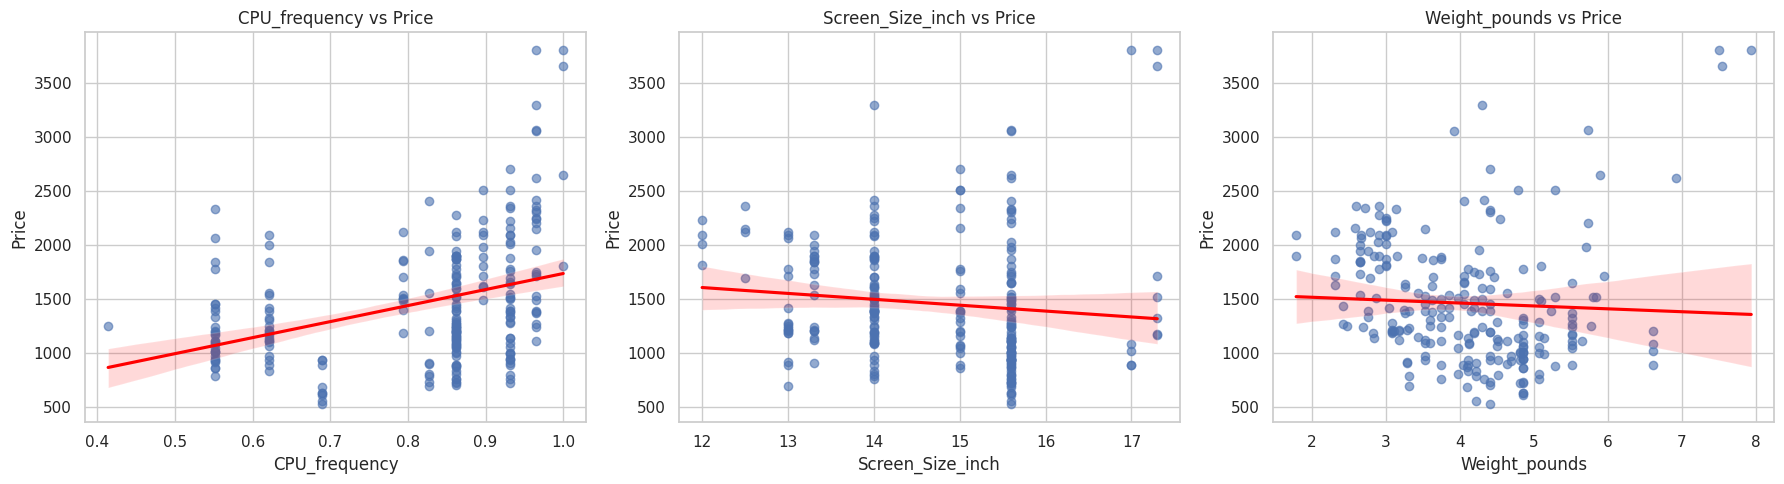

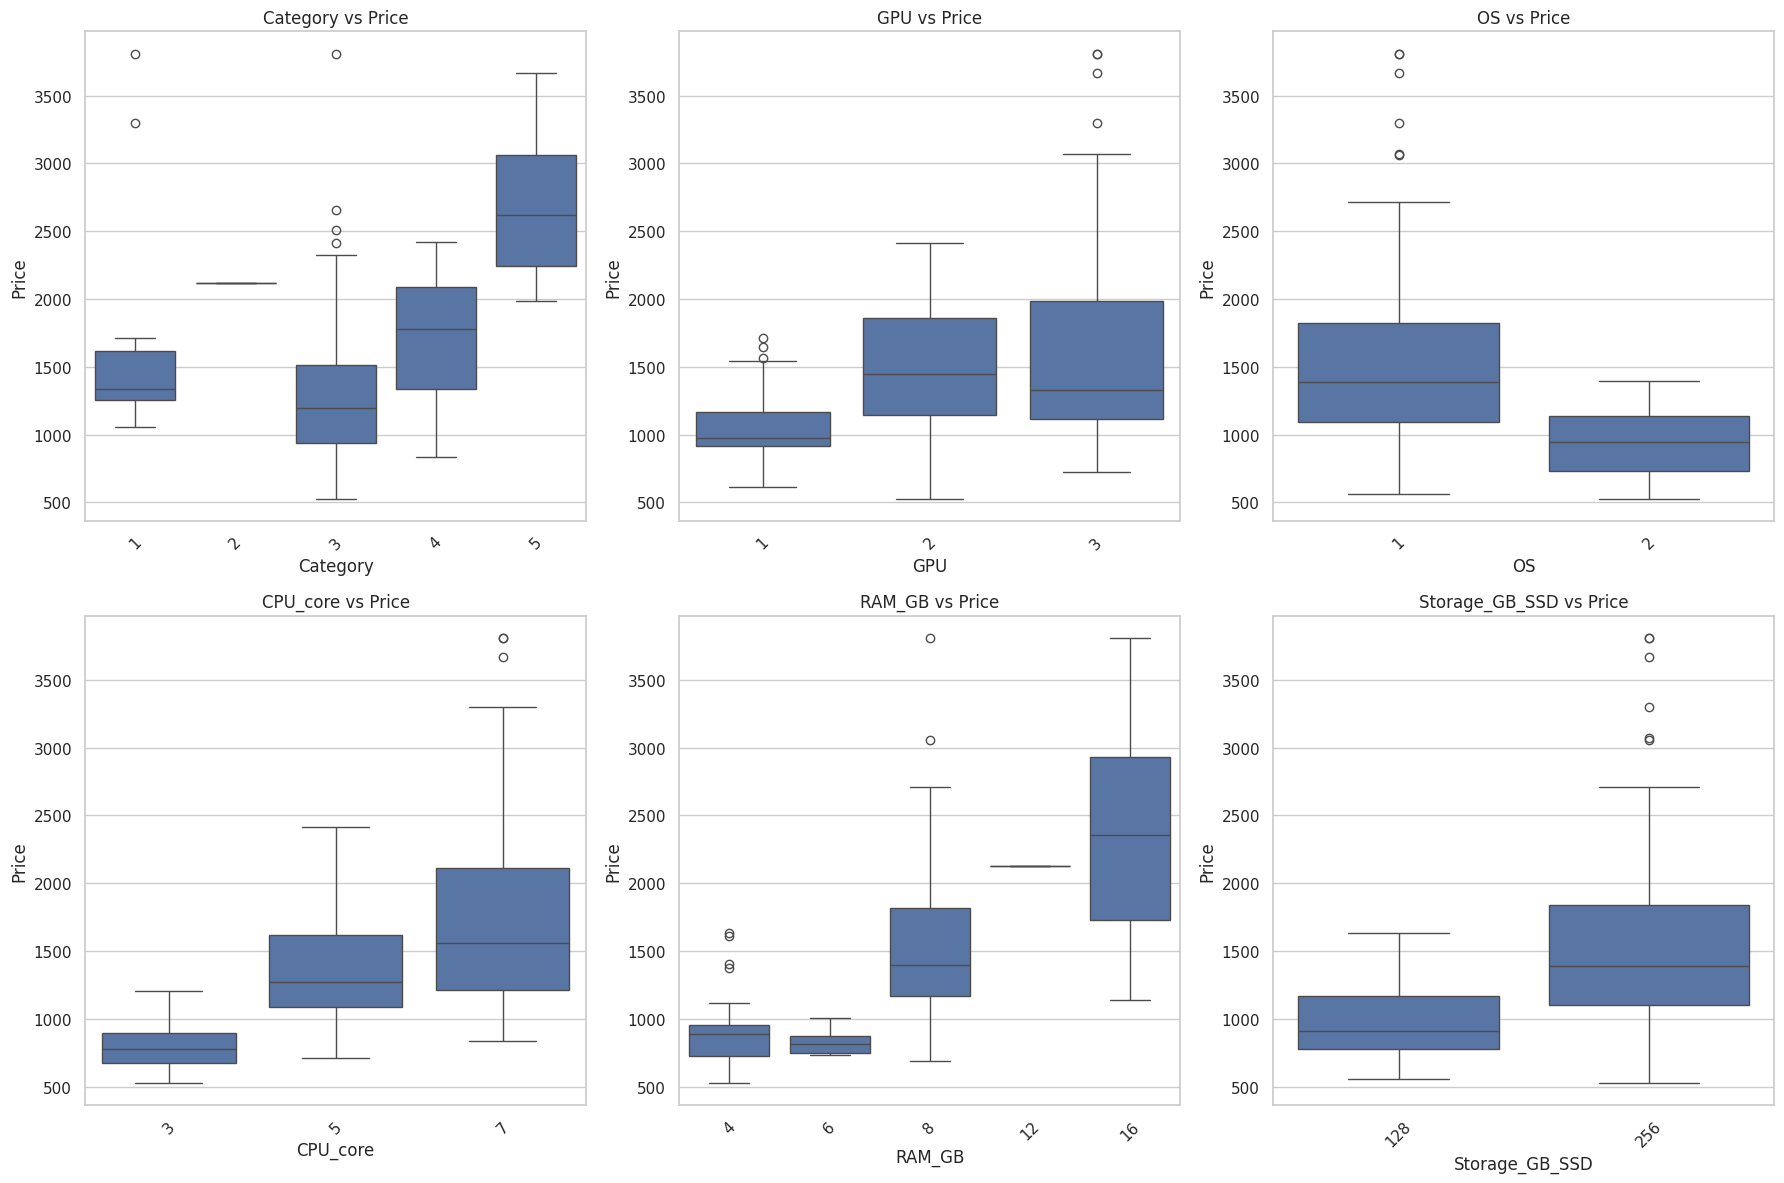

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("dataset1.csv", header=0)

# Set the visual style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Regression plots against Price
# ---------------------------------------------------------

regression_attributes = [
    "CPU_frequency",
    "Screen_Size_inch",
    "Weight_pounds"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, attribute in zip(axes, regression_attributes):
    sns.regplot(
        data=df,
        x=attribute,
        y="Price",
        ax=ax,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )
    ax.set_title(f"{attribute} vs Price")
    ax.set_xlabel(attribute)
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Box plots against Price
# ---------------------------------------------------------

boxplot_attributes = [
    "Category",
    "GPU",
    "OS",
    "CPU_core",
    "RAM_GB",
    "Storage_GB_SSD"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, attribute in zip(axes, boxplot_attributes):
    sns.boxplot(
        data=df,
        x=attribute,
        y="Price",
        ax=ax
    )
    ax.set_title(f"{attribute} vs Price")
    ax.set_xlabel(attribute)
    ax.set_ylabel("Price")

    # Rotate labels when categories have long names
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
from scipy.stats import pearsonr

# Load the dataset
df = pd.read_csv("dataset1.csv", header=0)

target = "Price"

# Select only numerical attributes and exclude the target variable
numeric_columns = df.select_dtypes(include="number").columns
feature_columns = [column for column in numeric_columns if column != target]

results = []

for feature in feature_columns:
    # Use only rows where both feature and Price are present
    pair_data = df[[feature, target]].dropna()

    # Pearson correlation requires at least two values
    # and both columns must have more than one unique value
    if (
        len(pair_data) < 2
        or pair_data[feature].nunique() < 2
        or pair_data[target].nunique() < 2
    ):
        correlation_value = None
        pearson_coefficient = None
        p_value = None
    else:
        # Correlation value calculated using pandas
        correlation_value = pair_data[feature].corr(pair_data[target])

        # Pearson coefficient and p-value calculated using scipy
        pearson_coefficient, p_value = pearsonr(
            pair_data[feature],
            pair_data[target]
        )

    results.append({
        "Attribute": feature,
        "Correlation_Value": correlation_value,
        "Pearson_Coefficient": pearson_coefficient,
        "P_Value": p_value
    })

# Store all results in a single DataFrame
correlation_results = pd.DataFrame(results)

# Display the results
print(correlation_results)

           Attribute  Correlation_Value  Pearson_Coefficient       P_Value
0       Unnamed: 0.1           0.321933             0.321933  3.851058e-07
1         Unnamed: 0           0.321933             0.321933  3.851058e-07
2           Category           0.286243             0.286243  7.225696e-06
3                GPU           0.288298             0.288298  6.166950e-06
4                 OS          -0.221730            -0.221730  5.696643e-04
5           CPU_core           0.459398             0.459398  7.912950e-14
6   Screen_Size_inch          -0.110644            -0.110644  8.853398e-02
7      CPU_frequency           0.366666             0.366666  5.502463e-09
8             RAM_GB           0.549297             0.549297  3.681561e-20
9     Storage_GB_SSD           0.243421             0.243421  1.489892e-04
10     Weight_pounds          -0.050312            -0.050312  4.397694e-01
11    Screen-Full_HD          -0.021075            -0.021075  7.463568e-01
12  Screen-IPS_panel     

Pivot table:
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


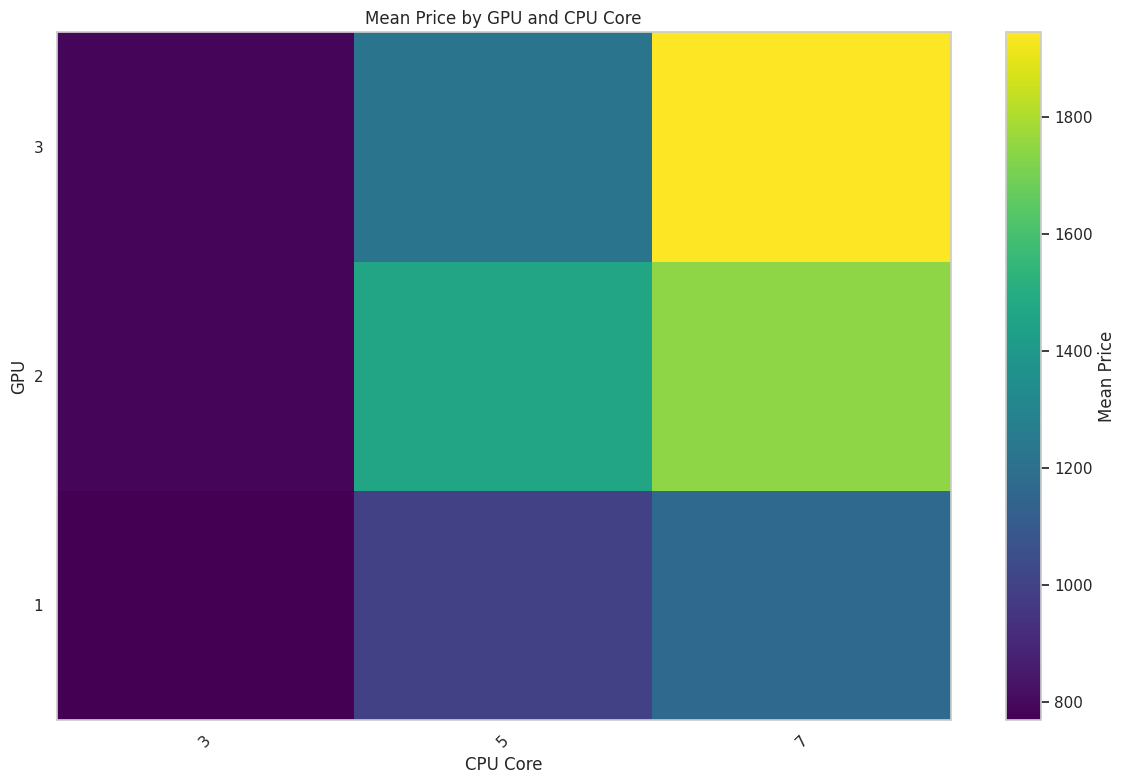

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Select the required attributes
grouped_data = df[["GPU", "CPU_core", "Price"]]

# Create a pivot table:
# Rows    -> GPU
# Columns -> CPU_core
# Values  -> Mean Price
pivot_table = pd.pivot_table(
    grouped_data,
    index="GPU",
    columns="CPU_core",
    values="Price",
    aggfunc="mean"
)

print("Pivot table:")
print(pivot_table)

# Convert the pivot table values to a NumPy array
plot_data = pivot_table.to_numpy(dtype=float)

# Create the pcolor plot
plt.figure(figsize=(12, 8))

pcolor_plot = plt.pcolor(
    plot_data,
    cmap="viridis",
    shading="auto"
)

# Add color bar
plt.colorbar(pcolor_plot, label="Mean Price")

# Set tick positions and labels
plt.xticks(
    np.arange(len(pivot_table.columns)) + 0.5,
    pivot_table.columns
)

plt.yticks(
    np.arange(len(pivot_table.index)) + 0.5,
    pivot_table.index
)

plt.xlabel("CPU Core")
plt.ylabel("GPU")
plt.title("Mean Price by GPU and CPU Core")

# Rotate labels for readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
